In [45]:
from google.colab import files

uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


# Retail Sales ETL & Exploratory Data Analysis

## Objective

This project demonstrates an end-to-end data analytics workflow involving:

- Extract, Transform and Load (ETL)
- Data Cleaning
- Feature Engineering
- SQL Analysis
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Business Insights

Dataset:
Sample Superstore Dataset

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

In [49]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("SampleSuperstore.csv")

Saving SampleSuperstore.csv to SampleSuperstore (2).csv


In [8]:
df.shape

(9977, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [52]:
df.head()
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [53]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.dropna(inplace=True)

In [57]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ","_")
      .str.replace("-","_")
)

In [58]:
cat_cols=[
'Ship_Mode',
'Segment',
'Country',
'City',
'State',
'Region',
'Category',
'Sub_Category'
]

for c in cat_cols:
    df[c]=df[c].astype("category")

In [59]:
df["Profit_Margin"]=(df["Profit"]/df["Sales"])*100

In [60]:
df["Revenue_Per_Item"]=df["Sales"]/df["Quantity"]

In [61]:
df["Loss"] = df["Profit"] < 0

In [62]:
df["Discount_Level"]=pd.cut(
    df["Discount"],
    bins=[-0.01,0,0.2,0.5,1],
    labels=[
        "No Discount",
        "Low",
        "Medium",
        "High"
    ]
)

In [63]:
conn=sqlite3.connect("sales.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

9977

In [64]:
df.describe()

,Postal_Code,Sales,Quantity,Discount,Profit,Profit_Margin,Revenue_Per_Item
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000,9977.000000,9977.000000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013,12.011354,60.985982
std,32058.266816,623.721409,2.226657,0.206455,234.45784,46.663769,143.029806
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800,-275.000000,0.336000
25%,23223.000000,17.300000,2.000000,0.000000,1.72620,7.500000,5.472000
50%,55901.000000,54.816000,3.000000,0.200000,8.67100,27.000000,16.272000
75%,90008.000000,209.970000,5.000000,0.200000,29.37200,36.250000,63.940000
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600,50.000000,3773.080000


In [24]:
query = """
SELECT SUM(Profit) AS Total_Profit
FROM sales;
"""

pd.read_sql(query, conn)

,Total_Profit
0,286241.4226


In [65]:
df.mean(numeric_only=True)

,0
Postal_Code,55154.964117
Sales,230.148902
Quantity,3.790719
Discount,0.156278
Profit,28.690130
Profit_Margin,12.011354
Revenue_Per_Item,60.985982
Loss,0.187331


In [67]:
df.median(numeric_only=True)

,0
Postal_Code,55901.000
Sales,54.816
Quantity,3.000
Discount,0.200
Profit,8.671
Profit_Margin,27.000
Revenue_Per_Item,16.272
Loss,0.000


In [68]:
df.mode().head(1)

,Ship_Mode,Segment,Country,City,State,Postal_Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Profit_Margin,Revenue_Per_Item,Loss,Discount_Level
0,Standard Class,Consumer,United States,New York City,California,10035,West,Office Supplies,Binders,12.96,3,0.0,0.0,35.0,6.48,False,No Discount


In [69]:
df.std(numeric_only=True)

,0
Postal_Code,32058.266816
Sales,623.721409
Quantity,2.226657
Discount,0.206455
Profit,234.457840
Profit_Margin,46.663769
Revenue_Per_Item,143.029806
Loss,0.390196


In [70]:
df.var(numeric_only=True)

,0
Postal_Code,1.027732e+09
Sales,3.890284e+05
Quantity,4.958001e+00
Discount,4.262375e-02
Profit,5.497048e+04
Profit_Margin,2.177507e+03
Revenue_Per_Item,2.045753e+04
Loss,1.522533e-01


In [30]:
df.isnull().sum()

,0
Ship_Mode,0
Segment,0
Country,0
City,0
State,0
Postal_Code,0
Region,0
Category,0
Sub_Category,0
Sales,0


In [71]:
df.skew(numeric_only=True)

,0
Postal_Code,-0.127166
Sales,12.963770
Quantity,1.276709
Discount,1.683386
Profit,7.554748
Profit_Margin,-2.894594
Revenue_Per_Item,10.776499
Loss,1.602946


In [72]:
df.kurt(numeric_only=True)

,0
Postal_Code,-1.493199
Sales,304.870940
Quantity,1.983746
Discount,2.406089
Profit,396.515988
Profit_Margin,10.177852
Revenue_Per_Item,197.546706
Loss,0.569549


In [74]:
query = '''
SELECT SUM(Sales)
FROM sales;
'''
pd.read_sql(query, conn)

,SUM(Sales)
0,2.296196e+06


In [80]:
query = ''' SELECT SUM(Profit)
FROM sales;
'''
pd.read_sql(query, conn)

,SUM(Profit)
0,286241.4226


In [81]:
query = '''
SELECT Category,
SUM(Sales) Sales
FROM sales
GROUP BY Category;
'''
pd.read_sql(query, conn)

,Category,Sales
0,Furniture,741306.3133
1,Office Supplies,718735.2440
2,Technology,836154.0330


In [ ]:
query = '''
SELECT Category,
SUM(Sales) Sales
FROM sales
GROUP BY Category;
'''
pd.read_sql(query, conn)

SyntaxError: invalid syntax (2432921096.py, line 1)

In [82]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Sales
0,Technology,836154.03
1,Furniture,741306.31
2,Office Supplies,718735.24


In [83]:
query = """
SELECT
    Category,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Profit
0,Technology,145454.95
1,Office Supplies,122364.66
2,Furniture,18421.81


In [84]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

pd.read_sql_query(query, conn)

,Region,Total_Sales
0,West,725255.64
1,East,678435.20
2,Central,500782.85
3,South,391721.91


In [85]:
query = """
SELECT
    Region,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query, conn)

,Region,Total_Profit
0,West,108329.81
1,East,91506.31
2,South,46749.43
3,Central,39655.88


In [86]:
query = """
SELECT
    City,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,City,Total_Sales
0,New York City,256319.04
1,Los Angeles,175831.90
2,Seattle,119460.28
3,San Francisco,112577.17
4,Philadelphia,109061.46
5,Houston,64441.26
6,Chicago,48535.98
7,San Diego,47521.03
8,Jacksonville,44713.18
9,Springfield,43054.34


In [87]:
query = """
SELECT
    Sub_Category,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM sales
GROUP BY Sub_Category
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Sub_Category,Total_Sales
0,Phones,330007.05
1,Chairs,327777.76
2,Storage,223843.61
3,Tables,206965.53
4,Binders,203409.17
5,Machines,189238.63
6,Accessories,167380.32
7,Copiers,149528.03
8,Bookcases,114880.00
9,Appliances,107532.16


In [88]:
query = """
SELECT
    Category,
    ROUND(AVG(Discount),2) AS Average_Discount
FROM sales
GROUP BY Category
ORDER BY Average_Discount DESC;
"""

pd.read_sql_query(query, conn)

,Category,Average_Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


In [89]:
query = """
SELECT
    Category,
    ROUND(AVG(Profit_Margin),2) AS Avg_Profit_Margin
FROM sales
GROUP BY Category
ORDER BY Avg_Profit_Margin DESC;
"""

pd.read_sql_query(query, conn)

,Category,Avg_Profit_Margin
0,Technology,15.61
1,Office Supplies,13.77
2,Furniture,3.87


In [90]:
query = """
SELECT
    City,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM sales
GROUP BY City
ORDER BY Total_Profit DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,City,Total_Profit
0,New York City,62013.90
1,Los Angeles,30431.43
2,Seattle,29121.68
3,San Francisco,17466.12
4,Detroit,13146.69
5,Lafayette,10018.39
6,Jackson,7581.68
7,Atlanta,6993.66
8,Minneapolis,6824.58
9,San Diego,6377.20


In [91]:
query = """
SELECT
    Discount_Level,
    COUNT(*) AS Number_of_Orders,
    ROUND(AVG(Profit),2) AS Average_Profit
FROM sales
GROUP BY Discount_Level
ORDER BY Number_of_Orders DESC;
"""

pd.read_sql_query(query, conn)

,Discount_Level,Number_of_Orders,Average_Profit
0,No Discount,4787,67.02
1,Low,3799,26.52
2,High,855,-89.54
3,Medium,536,-109.71


In [92]:
query = """
SELECT
    Category,
    SUM(CASE WHEN Loss = 1 THEN 1 ELSE 0 END) AS Loss_Making_Orders,
    COUNT(*) AS Total_Orders
FROM sales
GROUP BY Category;
"""

pd.read_sql_query(query, conn)

,Category,Loss_Making_Orders,Total_Orders
0,Furniture,713,2118
1,Office Supplies,885,6012
2,Technology,271,1847


In [93]:
conn.close()

In [94]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

df.head()

Number of Rows: 9977
Number of Columns: 17


,Ship_Mode,Segment,Country,City,State,Postal_Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Profit_Margin,Revenue_Per_Item,Loss,Discount_Level
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,130.9800,False,No Discount
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,243.9800,False,No Discount
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,7.3100,False,No Discount
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,191.5155,True,Medium
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,11.1840,False,Low


In [95]:
df.dtypes
df.isnull().sum()
print("Duplicate Rows:", df.duplicated().sum())
df.describe()



Duplicate Rows: 0


,Postal_Code,Sales,Quantity,Discount,Profit,Profit_Margin,Revenue_Per_Item
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000,9977.000000,9977.000000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013,12.011354,60.985982
std,32058.266816,623.721409,2.226657,0.206455,234.45784,46.663769,143.029806
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800,-275.000000,0.336000
25%,23223.000000,17.300000,2.000000,0.000000,1.72620,7.500000,5.472000
50%,55901.000000,54.816000,3.000000,0.200000,8.67100,27.000000,16.272000
75%,90008.000000,209.970000,5.000000,0.200000,29.37200,36.250000,63.940000
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600,50.000000,3773.080000


In [96]:
stats = pd.DataFrame({
    "Mean": df.select_dtypes(include="number").mean(),
    "Median": df.select_dtypes(include="number").median(),
    "Std Dev": df.select_dtypes(include="number").std()
})

stats

,Mean,Median,Std Dev
Postal_Code,55154.964117,55901.000,32058.266816
Sales,230.148902,54.816,623.721409
Quantity,3.790719,3.000,2.226657
Discount,0.156278,0.200,0.206455
Profit,28.690130,8.671,234.457840
Profit_Margin,12.011354,27.000,46.663769
Revenue_Per_Item,60.985982,16.272,143.029806


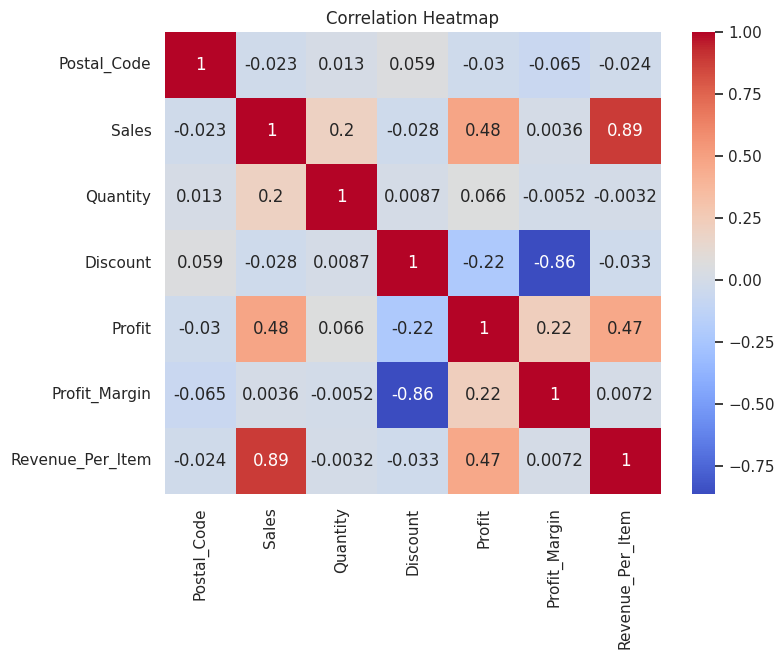

In [114]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

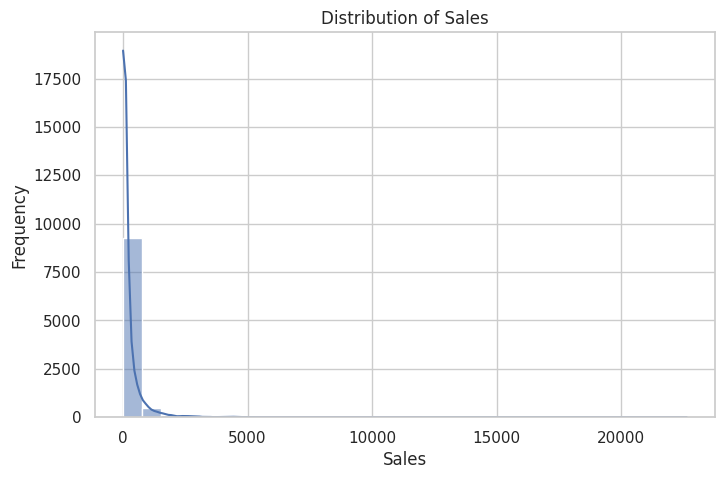

In [117]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("distribution of sales.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

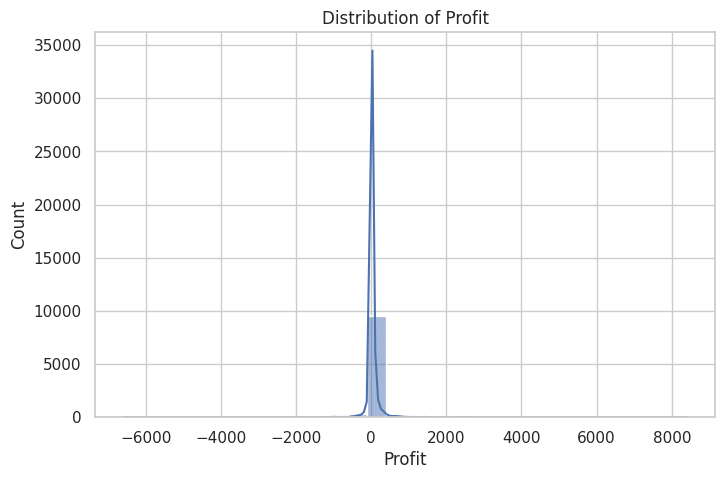

In [118]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.savefig("Distribution of Profit",
            dpi=300,
            bbox_inches="tight")

plt.show()

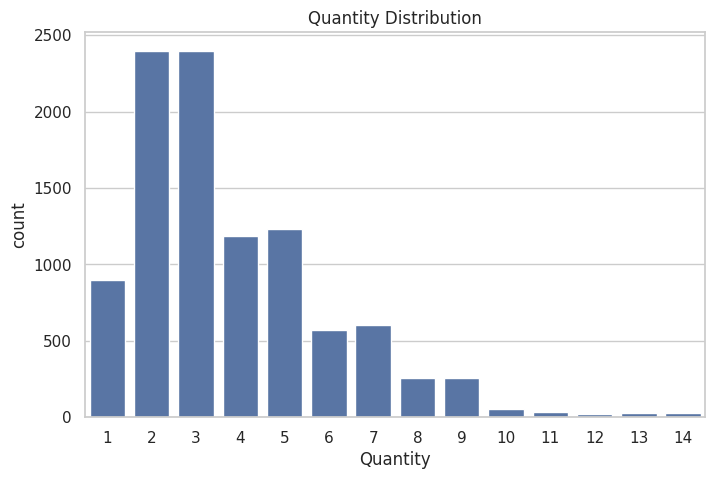

In [100]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Quantity")

plt.title("Quantity Distribution")

plt.show()

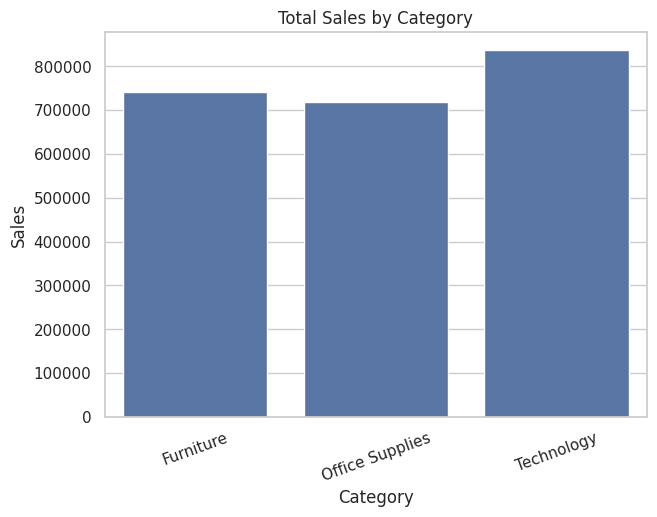

In [101]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator=sum,
    errorbar=None
)

plt.title("Total Sales by Category")

plt.xticks(rotation=20)

plt.show()

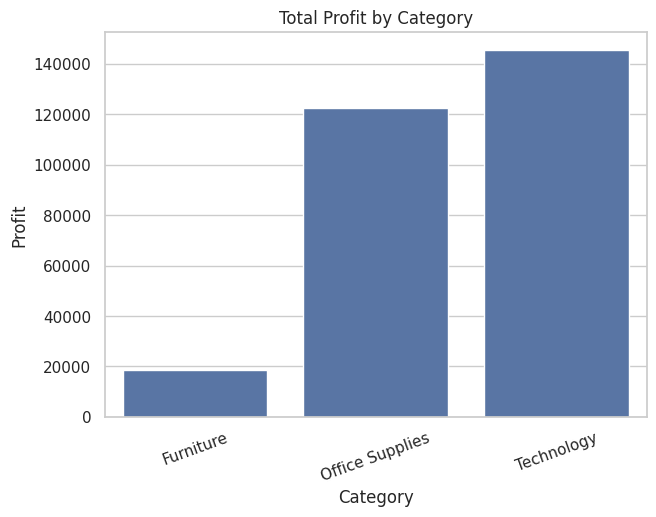

In [102]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Total Profit by Category")

plt.xticks(rotation=20)

plt.show()

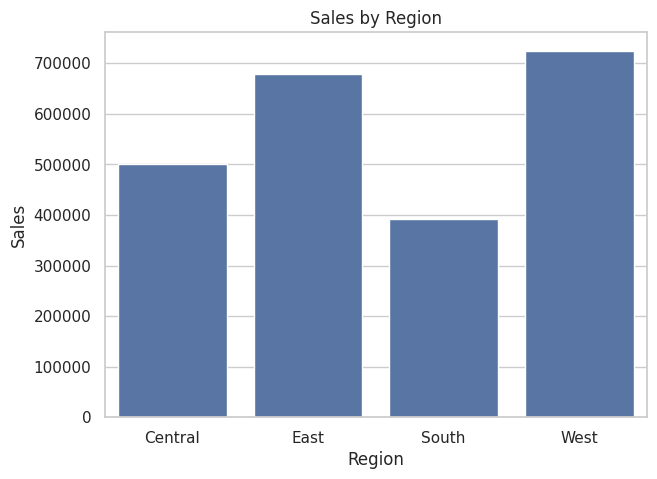

In [103]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator=sum,
    errorbar=None
)

plt.title("Sales by Region")

plt.show()

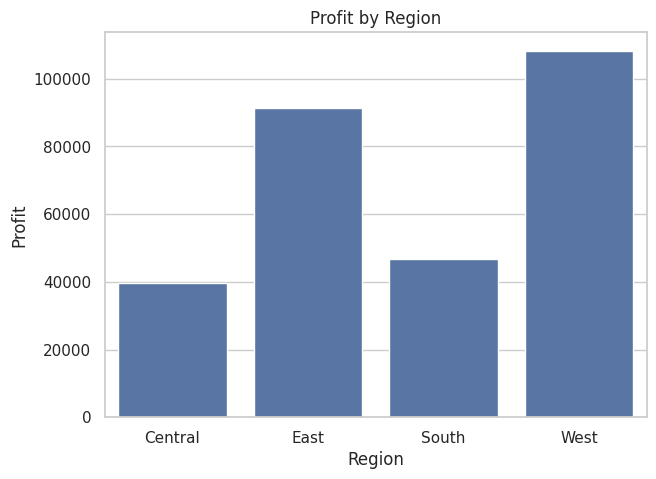

In [104]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Profit by Region")

plt.show()

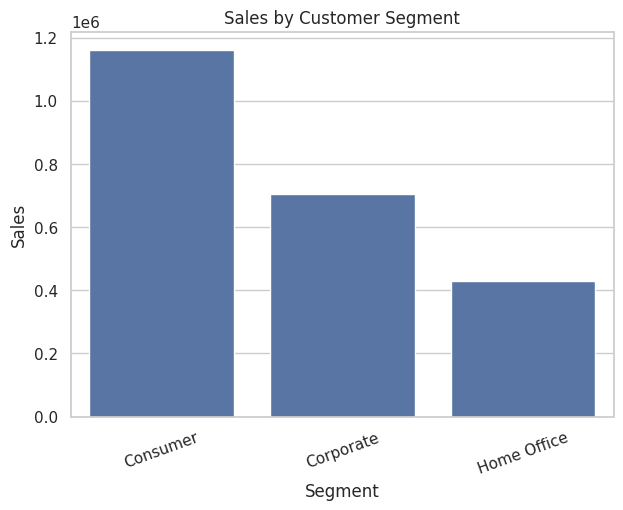

In [105]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Segment",
    y="Sales",
    estimator=sum,
    errorbar=None
)

plt.title("Sales by Customer Segment")

plt.xticks(rotation=20)

plt.show()

/tmp/ipykernel_1415/92271585.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("City")["Sales"]


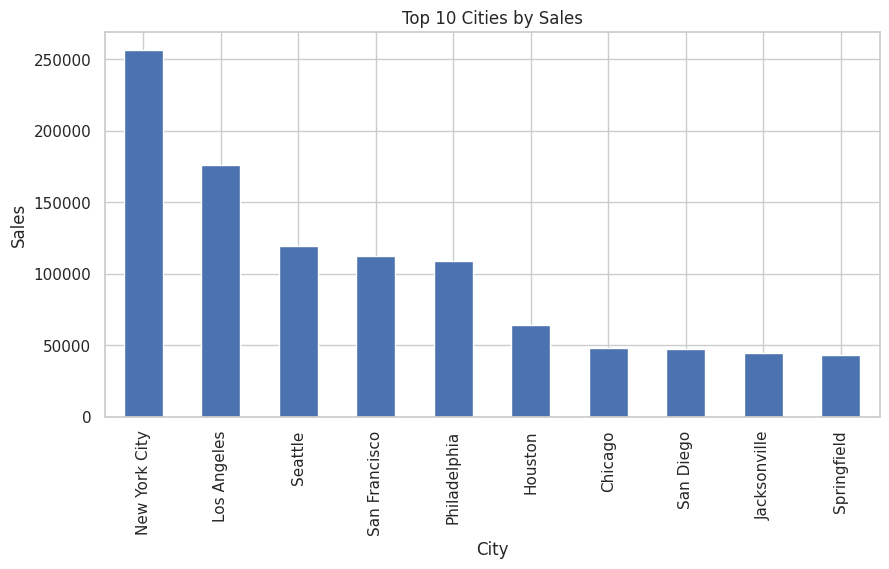

In [106]:
top_cities = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.ylabel("Sales")

plt.show()

/tmp/ipykernel_1415/3997946135.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Sub_Category")["Sales"]


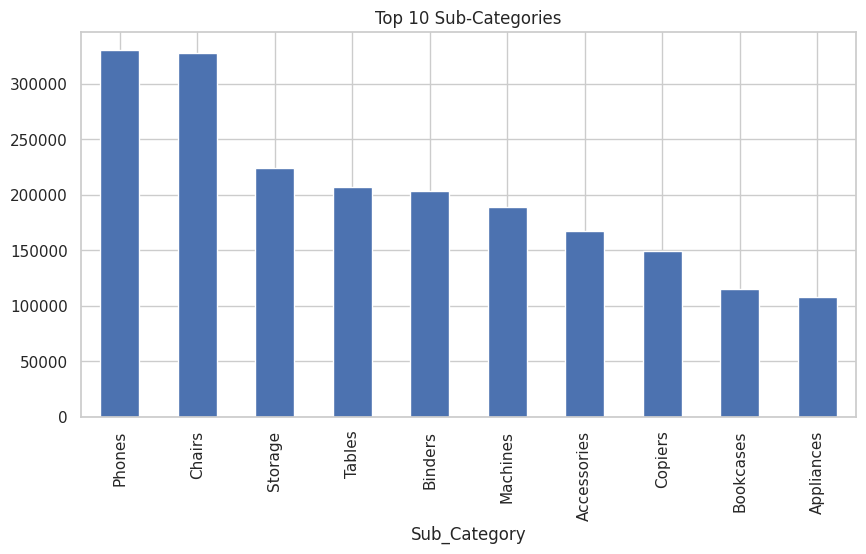

In [107]:
top_sub = (
    df.groupby("Sub_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_sub.plot(kind="bar")

plt.title("Top 10 Sub-Categories")

plt.show()

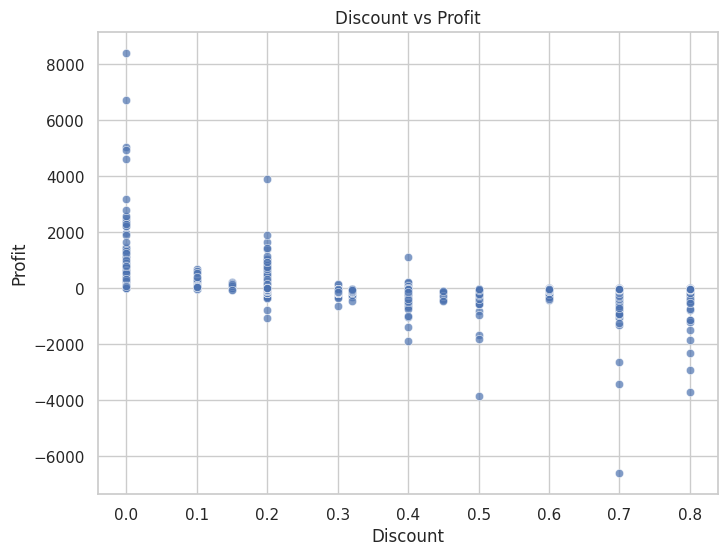

In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.7
)

plt.title("Discount vs Profit")

plt.show()

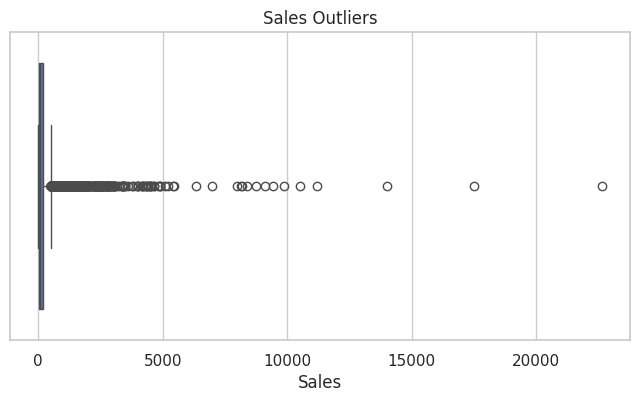

In [109]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outliers")

plt.show()

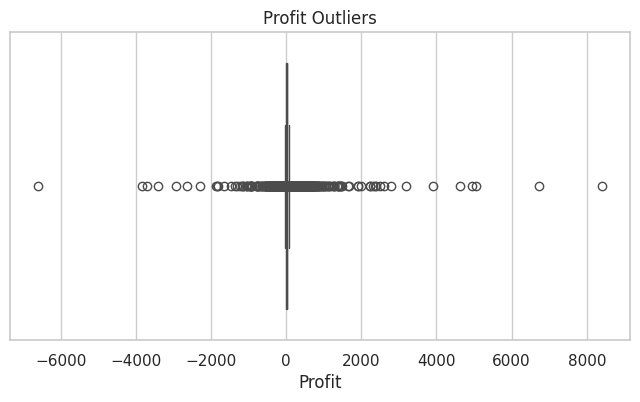

In [110]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Profit"])

plt.title("Profit Outliers")

plt.show()

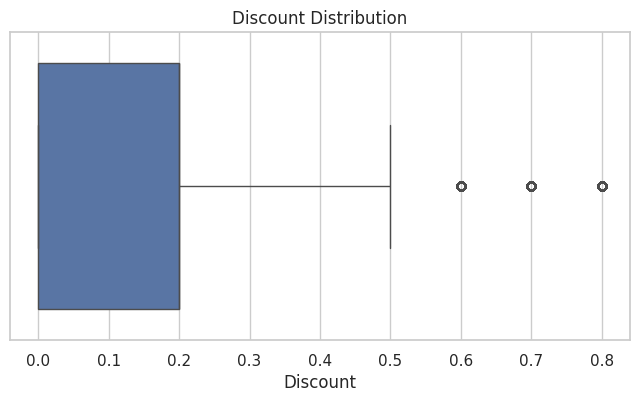

In [111]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Discount"])

plt.title("Discount Distribution")

plt.show()

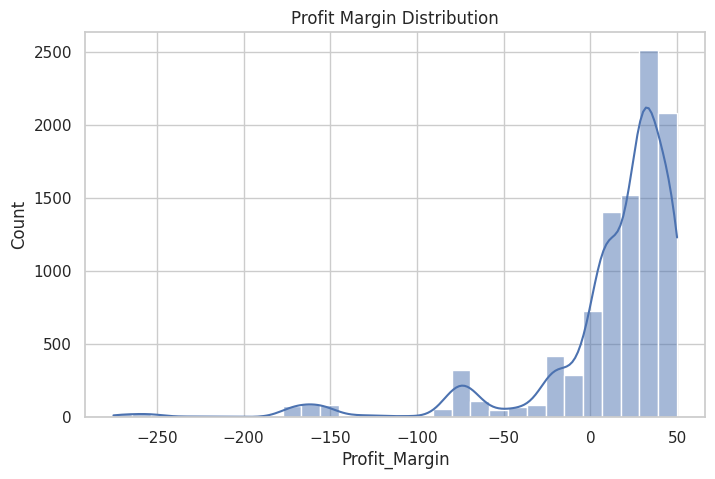

In [112]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit_Margin"], bins=30, kde=True)

plt.title("Profit Margin Distribution")

plt.show()

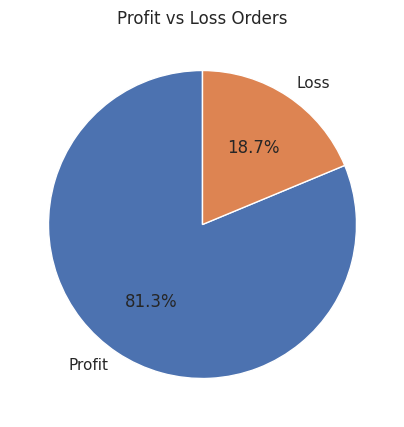

In [113]:
loss_counts = df["Loss"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    loss_counts,
    labels=["Profit", "Loss"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Profit vs Loss Orders")

plt.show()

/tmp/ipykernel_1415/2294342151.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Category")["Sales"].sum().plot(kind="bar", ax=axes[0,0])
/tmp/ipykernel_1415/2294342151.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Region")["Profit"].sum().plot(kind="bar", ax=axes[0,1])


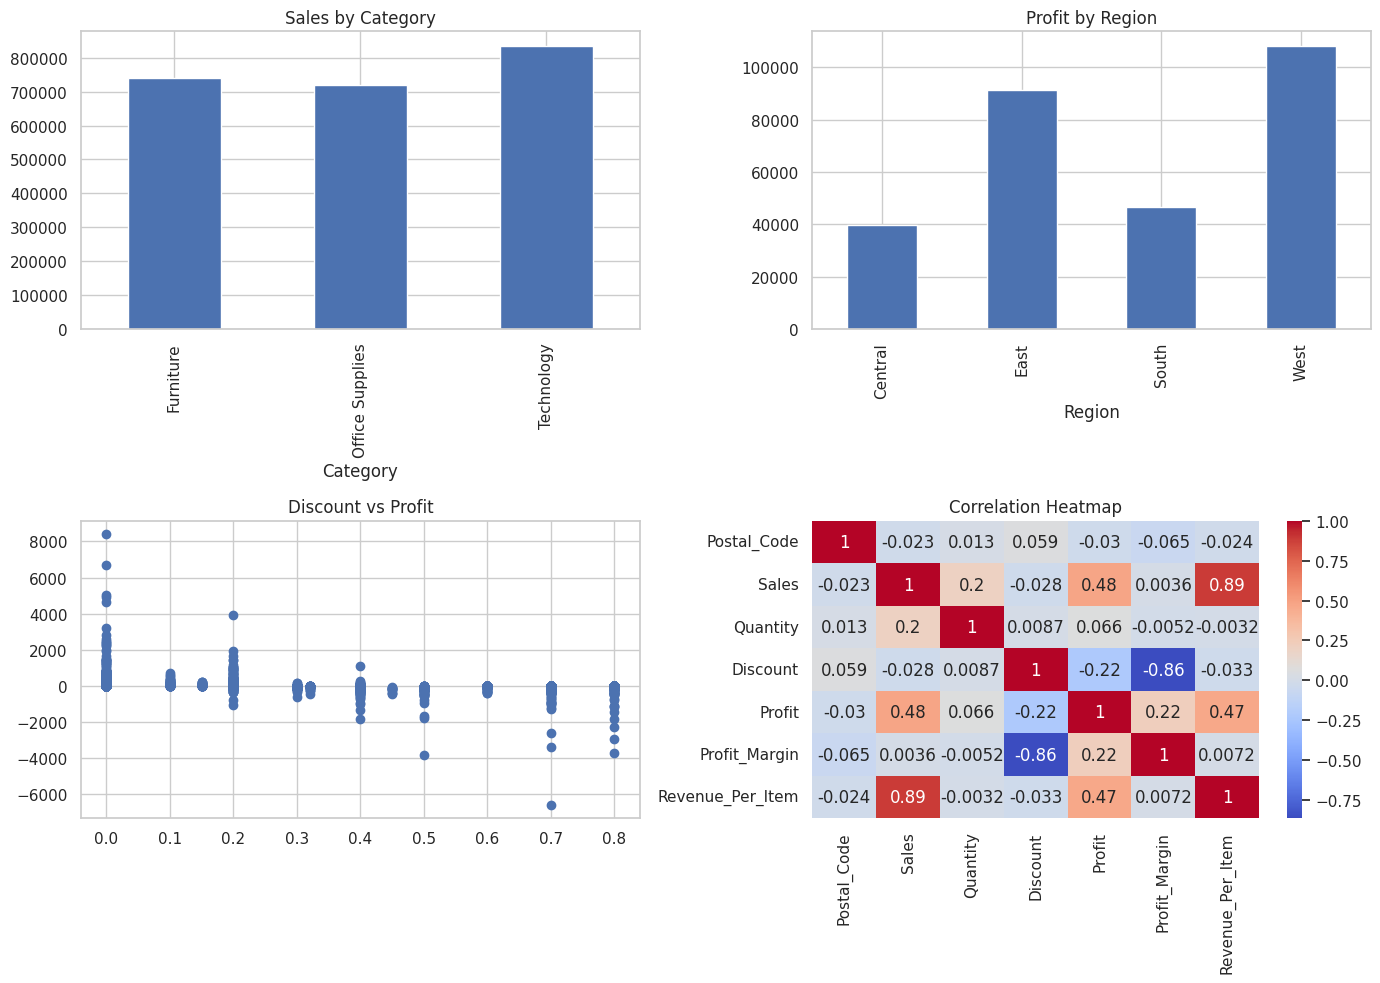

In [120]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Sales by Category
df.groupby("Category")["Sales"].sum().plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Sales by Category")

# Profit by Region
df.groupby("Region")["Profit"].sum().plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Profit by Region")

# Discount vs Profit
axes[1,0].scatter(df["Discount"], df["Profit"])
axes[1,0].set_title("Discount vs Profit")

# Correlation Heatmap
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1,1]
)
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("dashboard.png", dpi=300)
plt.show()

In [119]:
from google.colab import files
files.download("cleaned_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project successfully demonstrated an end-to-end data analytics workflow using the Sample Superstore dataset. The dataset was extracted, cleaned, transformed, and loaded into an SQLite database as part of the ETL process. Additional features such as Profit Margin, Revenue per Item, Loss Indicator, and Discount Level were engineered to enhance analytical capabilities.

SQL queries were used to generate key business metrics, including sales and profit by category, region, city, and sub-category. Exploratory Data Analysis (EDA) and statistical analysis helped identify sales trends, profitability patterns, outliers, and relationships between discounts and profits through various visualizations.

### Key Outcomes
- Successfully implemented an ETL pipeline using Python and SQLite.
- Performed descriptive statistics and exploratory data analysis on approximately 10,000 retail sales records.
- Identified high-performing categories, regions, and cities contributing to overall sales and profitability.
- Observed that higher discount levels were generally associated with lower profit margins.
- Generated actionable business insights using SQL queries and data visualizations to support data-driven decision-making.

Overall, this project demonstrates practical skills in data cleaning, feature engineering, SQL analysis, statistical analysis, and data visualization, reflecting a complete end-to-end data analysis workflow commonly used in real-world business intelligence and analytics projects.